In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\rag-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PARTE 1 — CARGA Y EXPLORACIÓN DE DATOS

In [4]:
ds = load_dataset("jskswamy/predictive-maintenance-data")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\rag-env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CHOPPE\.cache\huggingface\hub\datasets--jskswamy--predictive-maintenance-data. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order t

In [10]:
print(ds.shape)


{'train': (14650, 23), 'validation': (1954, 23), 'test': (2931, 23)}


In [12]:
train_df=ds["train"].to_pandas()
val_df=ds['validation'].to_pandas()
test_df=ds['test'].to_pandas()

In [13]:
train_df.head()

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,168.012736,...,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,0.071094,7.607961,161.419599,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,360.135302,...,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,0.093024,14.922979,152.464814,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,237.550882,...,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,0.073284,10.985159,162.319576,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,342.677654,...,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,0.055722,12.555685,148.415905,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,300.271898,...,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,0.070473,11.703479,162.622677,0


In [16]:
print(f"train: {train_df.shape}")
print(f"val: {val_df.shape}")
print(f"test: {test_df.shape}")

train: (14650, 23)
val: (1954, 23)
test: (2931, 23)


In [18]:
#Concatenar todo en un dataframe 
df=pd.concat([train_df, val_df,test_df], ignore_index=True)

print("Dataset completo:", df.shape)
df.head()

Dataset completo: (19535, 23)


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,1182,2.171086,3.859666,1.577209,77.386491,84.033108,2566.223784,4562.124881,1864.260860,168.012736,...,-6.646617,0.562506,0.726460,0.028055,53.279599,0.065471,0.071094,7.607961,161.419599,0
1,809,4.664445,7.566739,2.691795,77.208609,75.256205,3773.535904,6121.492048,2177.662284,360.135302,...,1.952404,0.616440,0.577088,0.060414,27.957617,0.095437,0.093024,14.922979,152.464814,0
2,1060,2.806662,6.863467,1.315029,84.638218,77.681358,2975.061886,7275.275508,1393.931263,237.550882,...,6.956860,0.408928,0.468538,0.033161,59.071906,0.079847,0.073284,10.985159,162.319576,0
3,1306,4.530173,5.348519,2.676993,75.643400,72.772505,5916.405358,6985.165653,3496.153265,342.677654,...,2.870895,0.846996,0.590925,0.059889,27.184408,0.057920,0.055722,12.555685,148.415905,0
4,1123,3.596866,5.056221,3.050392,83.481538,79.141139,4039.280403,5678.136200,3425.589979,300.271898,...,4.340399,0.711374,0.848069,0.043086,25.944573,0.074338,0.070473,11.703479,162.622677,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Engine RPM                     19535 non-null  int64  
 1   Lub Oil Pressure               19535 non-null  float64
 2   Fuel Pressure                  19535 non-null  float64
 3   Coolant Pressure               19535 non-null  float64
 4   Lub Oil Temp                   19535 non-null  float64
 5   Coolant Temp                   19535 non-null  float64
 6   RPM_x_OilPressure              19535 non-null  float64
 7   RPM_x_FuelPressure             19535 non-null  float64
 8   RPM_x_CoolantPressure          19535 non-null  float64
 9   OilTemp_x_OilPressure          19535 non-null  float64
 10  CoolantTemp_x_CoolantPressure  19535 non-null  float64
 11  RPM_squared                    19535 non-null  int64  
 12  OilPressure_squared            19535 non-null  float64
 1

In [24]:
columnas=df.columns.tolist()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine RPM,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2.239000e+03
Lub Oil Pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566e+00
Fuel Pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,2.113833e+01
Coolant Pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505e+00
Lub Oil Temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,8.958080e+01
Coolant Temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,1.955279e+02
RPM_x_OilPressure,19535.0,2620.923894,1243.143436,1.326572,1739.171156,2383.271067,3265.915016,1.190009e+04
RPM_x_FuelPressure,19535.0,5265.023724,2929.726204,2.715436,3319.939826,4604.612330,6451.679249,3.111816e+04
RPM_x_CoolantPressure,19535.0,1840.907931,1052.535810,1.511984,1127.594910,1588.671030,2280.180318,1.166476e+04
OilTemp_x_OilPressure,19535.0,256.490880,79.881621,0.249275,195.357046,245.395639,315.445690,5.618897e+02


In [27]:
print("Dimensiones del dataset")
print("--"*60)
print(f"Numero de columnas (VARIABLES): {df.shape[1]}")
print(f"Numero de filas (MEDICIONES): {df.shape[0]}")

Dimensiones del dataset
------------------------------------------------------------------------------------------------------------------------
Numero de columnas (VARIABLES): 23
Numero de filas (MEDICIONES): 19535


In [44]:
from pprint import pprint
columnas_enteros=df.select_dtypes(include=int).columns
columnas_float=df.select_dtypes(include=float).columns

print(f"\nNumero de columnas con valores de tipo int:\n{len(columnas_enteros)}: {columnas_enteros}")

print(f"\nNumero de columnas con valores de tipo int:\n{len(columnas_float)}: {columnas_float}")


Numero de columnas con valores de tipo int:
3: Index(['Engine RPM', 'RPM_squared', 'Engine Condition'], dtype='str')

Numero de columnas con valores de tipo int:
20: Index(['Lub Oil Pressure', 'Fuel Pressure', 'Coolant Pressure', 'Lub Oil Temp',
       'Coolant Temp', 'RPM_x_OilPressure', 'RPM_x_FuelPressure',
       'RPM_x_CoolantPressure', 'OilTemp_x_OilPressure',
       'CoolantTemp_x_CoolantPressure', 'OilPressure_squared', 'TempDiff',
       'OilFuelPressureRatio', 'CoolantOilPressureRatio', 'OilHealthIndex',
       'CoolantStress', 'OilTempPerRPM', 'CoolantTempPerRPM', 'PressureSum',
       'TempSum'],
      dtype='str')


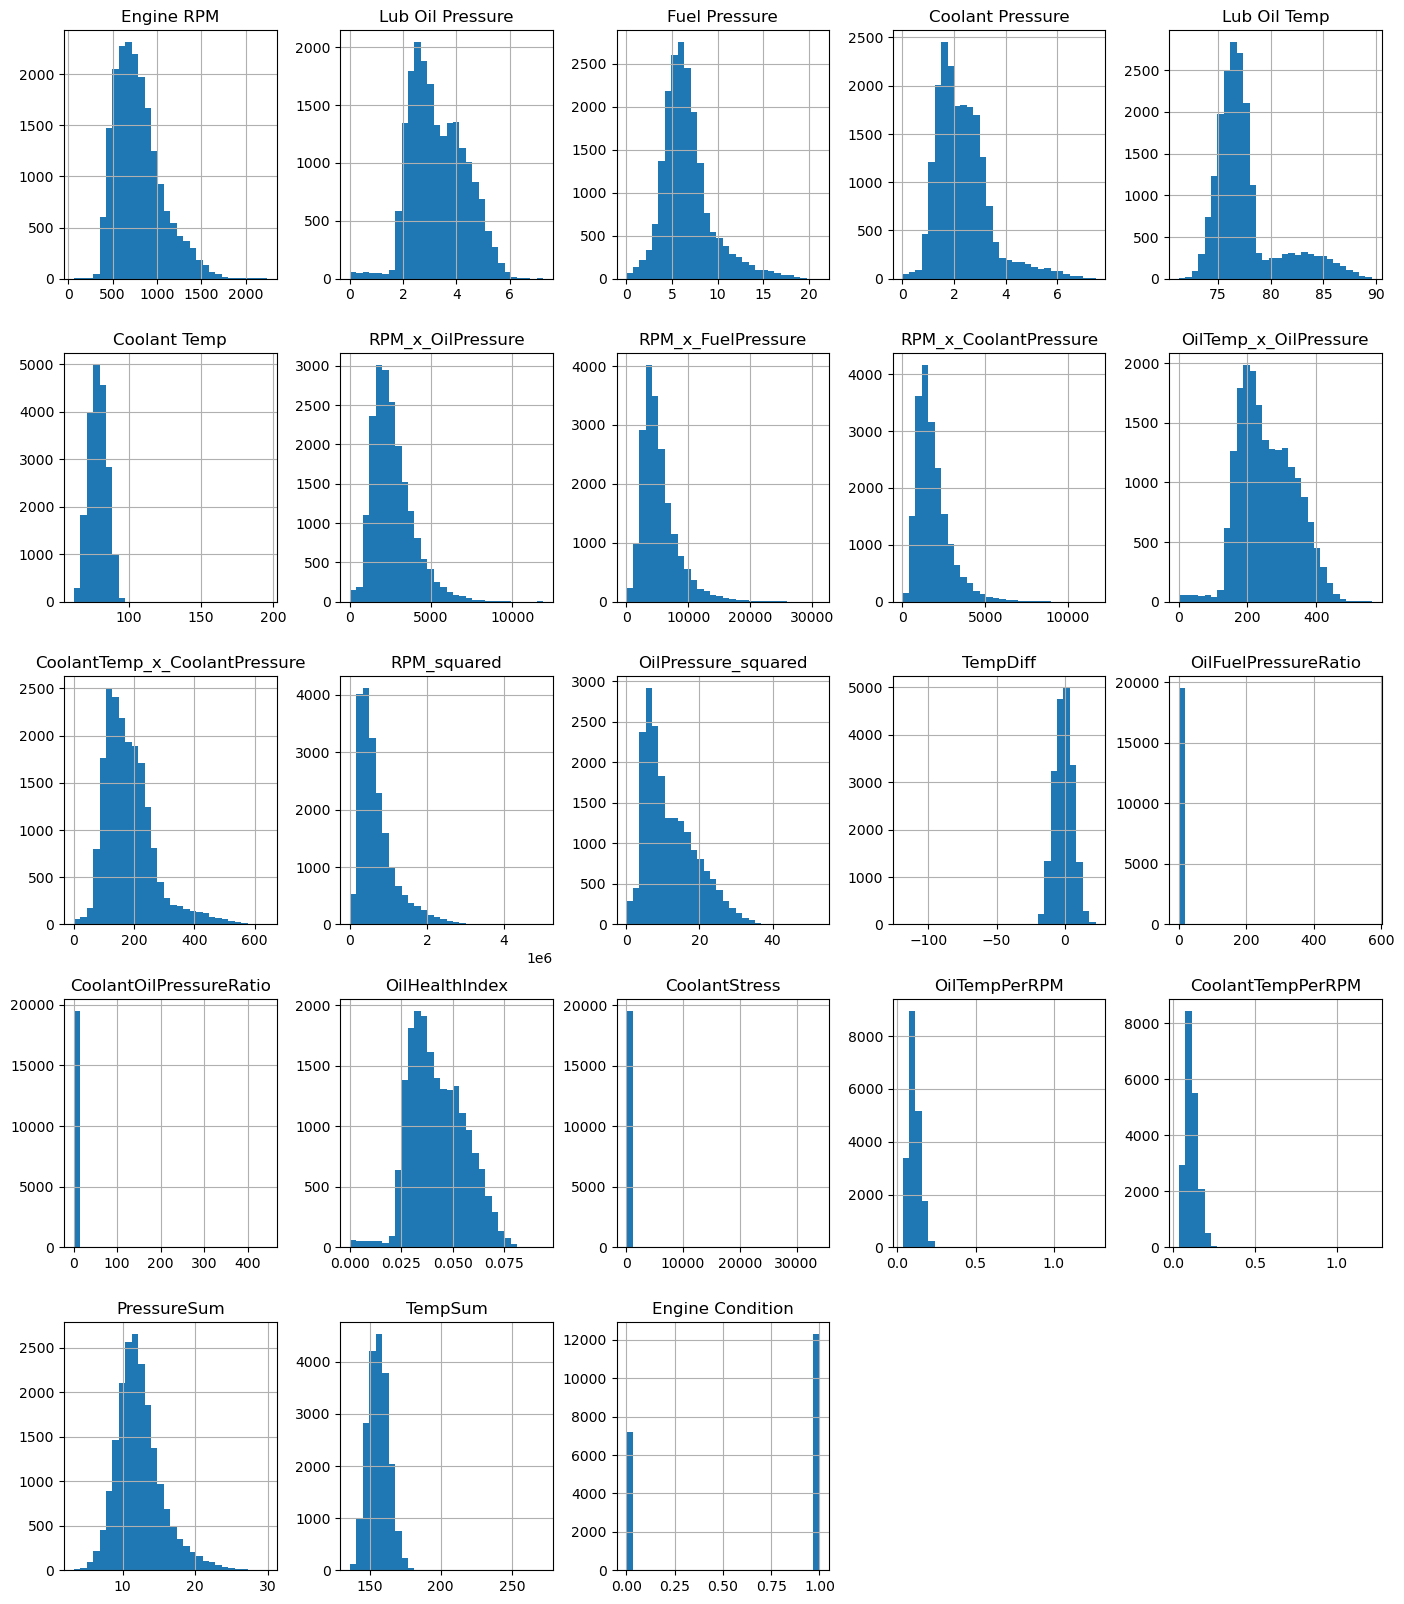

In [55]:
df.hist(bins=30, figsize=(17,20))
plt.show()

In [60]:
df.isnull().sum()

Engine RPM                       0
Lub Oil Pressure                 0
Fuel Pressure                    0
Coolant Pressure                 0
Lub Oil Temp                     0
Coolant Temp                     0
RPM_x_OilPressure                0
RPM_x_FuelPressure               0
RPM_x_CoolantPressure            0
OilTemp_x_OilPressure            0
CoolantTemp_x_CoolantPressure    0
RPM_squared                      0
OilPressure_squared              0
TempDiff                         0
OilFuelPressureRatio             0
CoolantOilPressureRatio          0
OilHealthIndex                   0
CoolantStress                    0
OilTempPerRPM                    0
CoolantTempPerRPM                0
PressureSum                      0
TempSum                          0
Engine Condition                 0
dtype: int64

<Axes: >

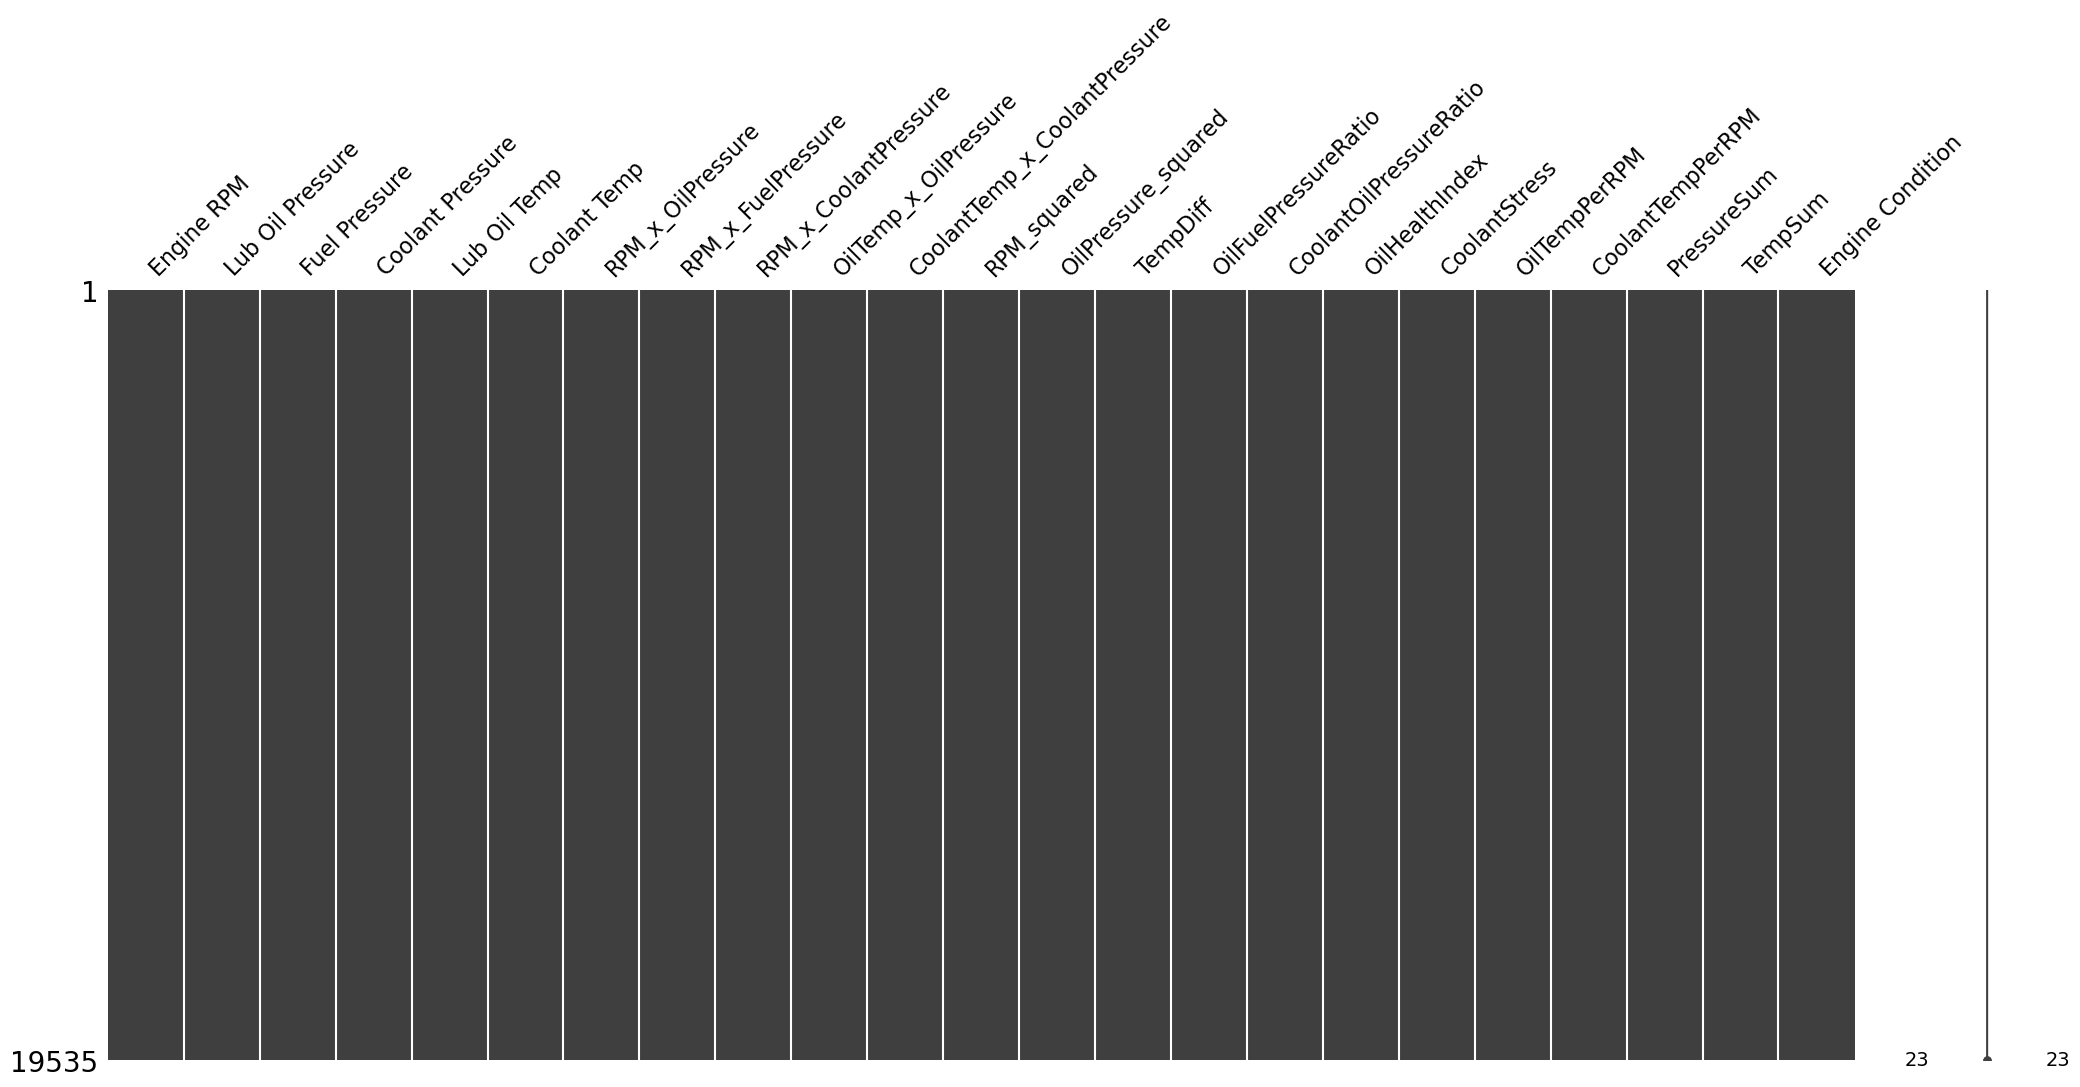

In [ ]:
import missingno as msno
msno.matrix(df)


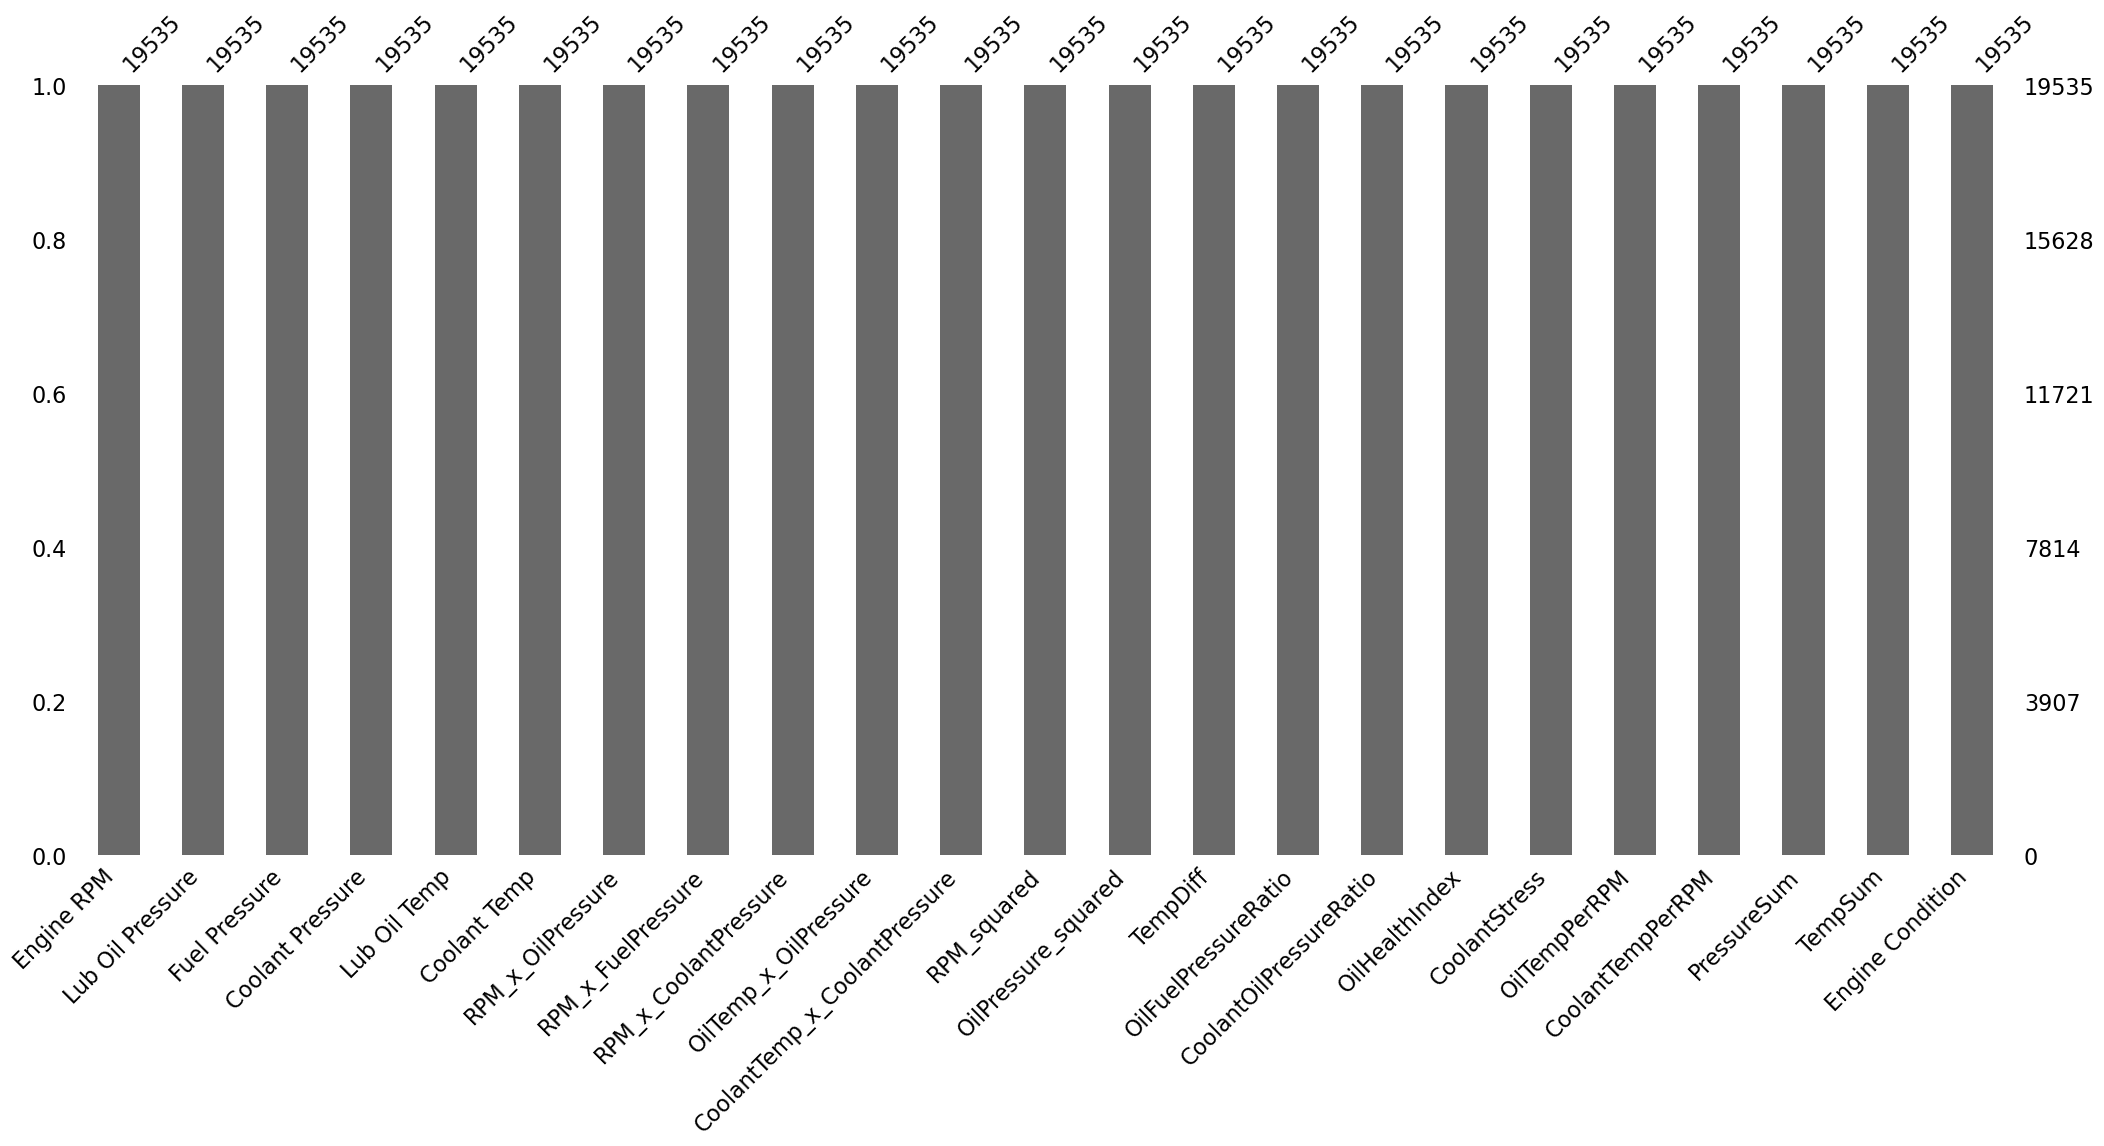

In [64]:
msno.bar(df)
plt.show()

In [74]:
round(df["Engine Condition"].value_counts(normalize=True)*100,2)

Engine Condition
1    63.05
0    36.95
Name: proportion, dtype: float64

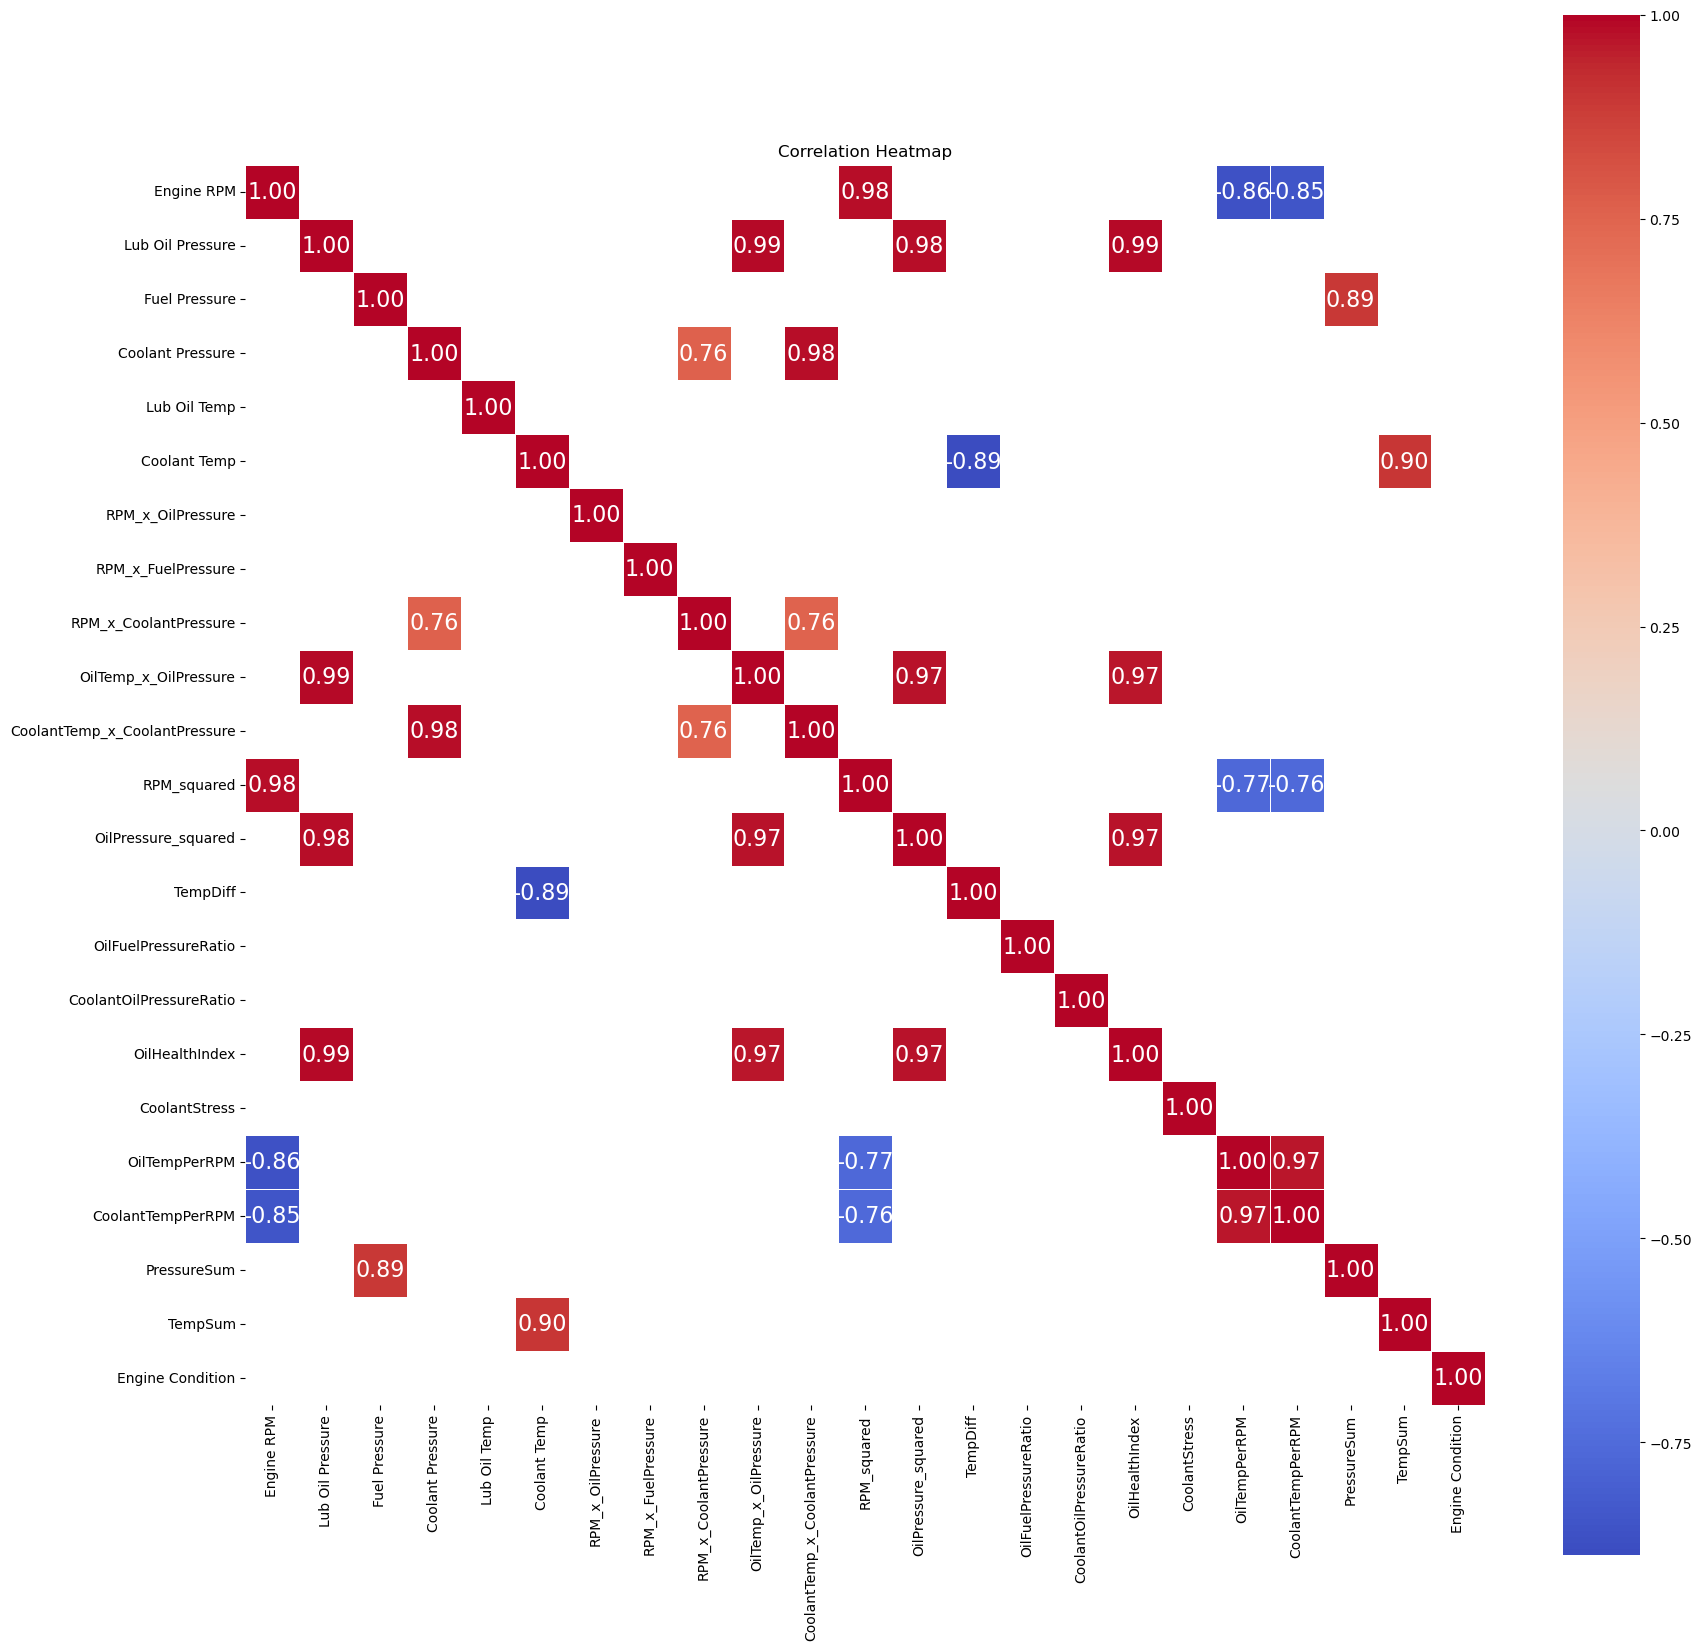

In [103]:
#Existen clases desbalanceadas analizemos correlación entre variables
import seaborn as sns
corr = df.corr(numeric_only=True)

threshold = 0.75

corr_filtrado = corr[(corr.abs() > threshold)]

plt.figure(figsize=(20,20))
sns.heatmap(corr_filtrado,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            annot_kws={"size": 16},
            square=True


            )
plt.title("Correlation Heatmap")
plt.show()

In [104]:
import networkx as nx

# matriz de correlación
corr = df.corr(numeric_only=True)

# threshold
threshold = 0.8

# crear grafo
G = nx.Graph()

# agregar nodos
for col in corr.columns:
    G.add_node(col)

# agregar edges (conexiones)
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])

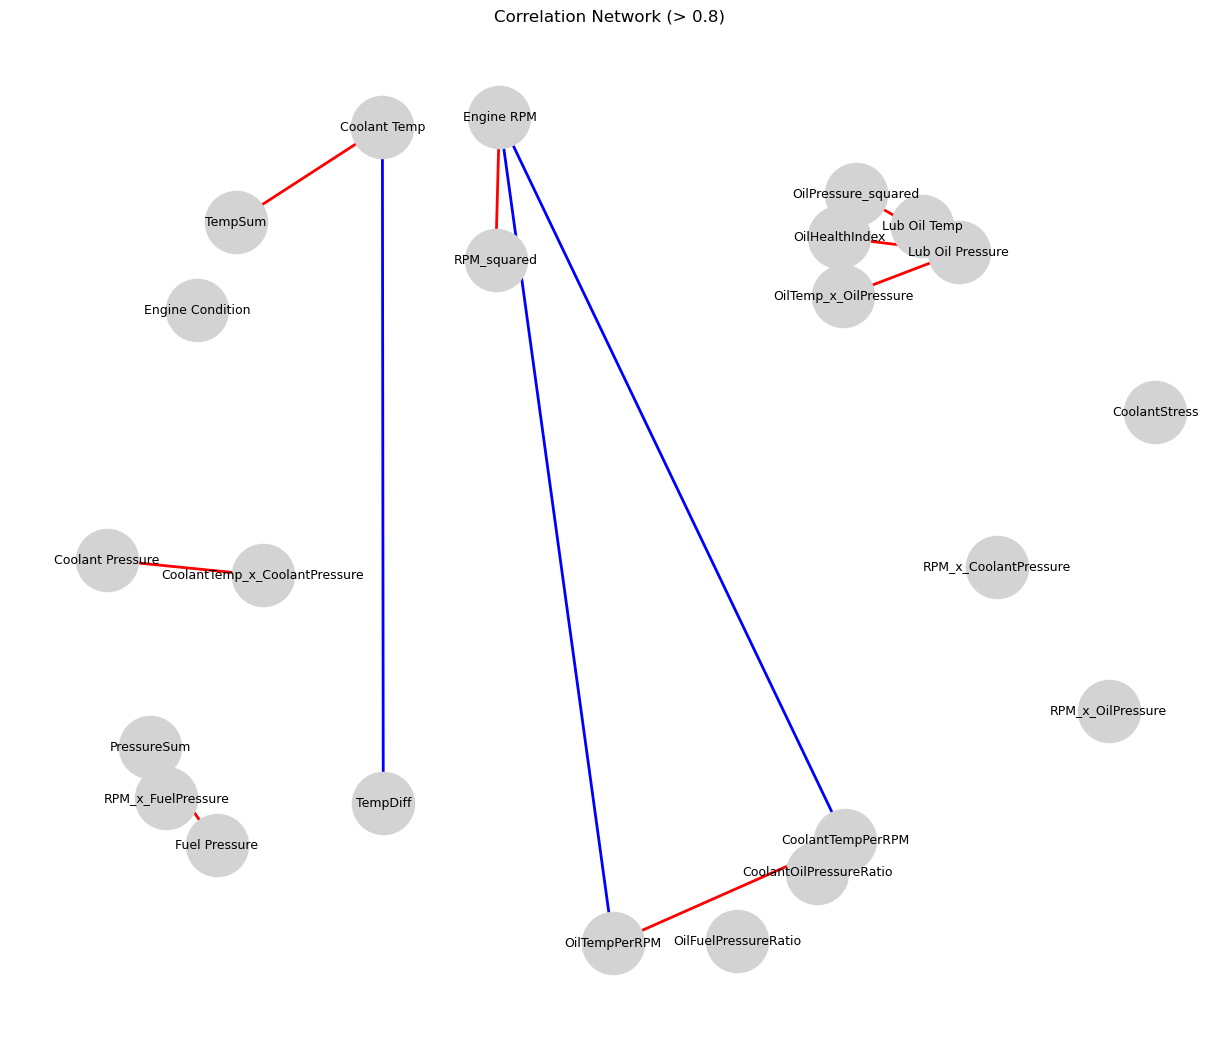

In [105]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.5, seed=42)

edges = G.edges(data=True)

# colores según correlación
edge_colors = ['red' if e[2]['weight'] > 0 else 'blue' for e in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='lightgray',
    font_size=9,
    edge_color=edge_colors,
    width=2
)

plt.title("Correlation Network (> 0.8)")
plt.show()

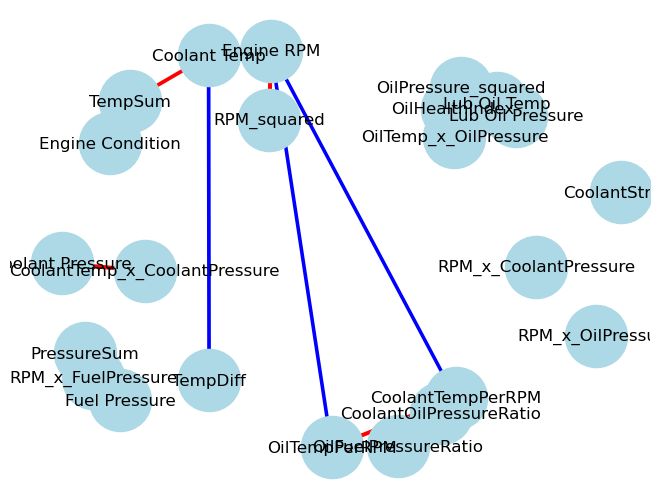

In [106]:
weights = [abs(e[2]['weight']) * 3 for e in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    edge_color=edge_colors,
    width=weights
)